# 1. Data collection and preprocessing
This repository detailed the list of processing and analysis how to retrieve a continuous diurnal LST during peak summer months with high spatial resolution.

| Data                 | Data source     | Access / Download source                                               | Preprocessing | Reference                              |
|----------------------|-----------------|------------------------------------------------------------------------|---------------|----------------------------------------|
| Daytime and Nighttime – Coarse     | MODIS           | APPEEARS - https://appeears.earthdatacloud.nasa.gov/                   | OSGeo4W Shell | [Modis_preprocessing](preprocessing/modis.txt)     |
| 		       | Himawari SST    | WinSCP - https://winscp.net/eng/download.php                           | OSGeo4W Shell | [Himawari_preprocessing](preprocessing/himawari.txt)  |
| Daytime – Fine       | Landsat 8 and 9 | Google Earth Engine - GEE code (Ermida et al., 2020) https://github.com/sofiaermida/Landsat_SMW_LST                  | GEE | [Landsat_preprocessing](preprocessing/landsat.txt)   |
| Nighttime – Fine   | ECOSTRESS       | APPEEARS - https://appeears.earthdatacloud.nasa.gov/                   | ArcGIS - Spatial analyst | Mosaic and Raster calculator to convert Kelvin into Celcius |

# 2. Data description

In [1]:
import pandas as pd
# load the list of images
image_list = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\xlsx\list_of_images_csv.csv")

# Preview first 40 rows
display(image_list.head(40))

,spatial,temporal,use,date,view_time_UTC,view_time_AEDT,file_ID
0,Fine,Daytime,Reference,7/01/2023,7/01/2023 0:04,7/01/2023 11:04,LC80920862023007LGN00
1,Fine,Daytime,Validation,8/01/2021,8/01/2021 0:10,8/01/2021 11:10,LC80930862021008LGN00
2,Fine,Daytime,Validation,19/01/2022,19/01/2022 0:10,19/01/2022 11:10,LC90930862022019LGN01
3,Fine,Daytime,Validation,20/01/2022,20/01/2022 0:04,20/01/2022 11:04,LC80920872022020LGN00
4,Fine,Nighttime,Reference,25/12/2022,25/12/2022 12:50,25/12/2022 23:50,ECO_L2T_LSTE.002_LST_doy2022359124954_aid0001_55S
5,Fine,Nighttime,Reference,25/12/2022,25/12/2022 12:50,25/12/2022 23:50,ECO_L2T_LSTE.002_LST_doy2022359125046_aid0001_55S
6,Fine,Nighttime,Validation,12/12/2021,12/12/2021 11:22,12/12/2021 22:22,ECO_L2T_LSTE.002_LST_doy2021346112222_aid0001_55S
7,Fine,Nighttime,Validation,9/02/2023,9/02/2023 12:50,9/02/2023 23:50,ECO_L2T_LSTE.002_LST_doy2023040114723_aid0001_55S
8,Coarse,Daytime,Reference,7/01/2023,6/01/2023 22:48,7/01/2023 9:48,MOD11A1.061_LST_Day_1km_doy2023007000000_aid0001
9,Coarse,Daytime,Validation,8/01/2021,7/01/2021 23:54,8/01/2021 10:54,MOD11A1.061_LST_Day_1km_doy2021008000000_aid0001


# 2. Coarse images: Mosaicking, Reprojection, Resampling
The STARFM preprocessing steps are shown below

## 2.2 Daytime
The himawari image does not fully cover the Port Philip bay. Extrapolation using IDW was conducted. The original resolution was 2km. It was resampled to 1km to fit with the MODIS data. Then the SST in the study area is extracted using this file
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\ppb_square_b.7z

Extraction of the MODIS using a full rectangle with width and height values multiple by 1km (Unit of MODIS)
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\MODIS_fishnet_diss.7z

After alignment with the reference extract the output using
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\MODIS_extractByMask.7z

Resampling to 30 m (Reference fine = Landasat). 
Corresponding file to get the width and height (same extent as reference image), the following file was used
C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\shapefile\modis_30m_fish_diss_e.7z

## 2.3 Nightime
Resampling to 70 m (Reference fine = ECOSTRESS).
Corresponding file to get the width and height (same extent as reference image), the following file was used

The full preprocessing workflow is available at:
- [Daytime data processing](preprocessing/daytime_preprocessing.txt)
- [Nighttime data processing](preprocessing/nighttime_preprocessing.txt)

# 3. STARFM
To run STARFM, the following repository was used (Mileva et al. 2018)
https://github.com/nmileva/starfm4py?tab=readme-ov-file

[STARFM parameters](preprocessing/starfm_parameters.txt) 



## 3.1 Some scenes of observed and predicted LST

## 3.1. Comparison against air temperature at BOM stations
The LST data for the target dates were compared with air temperature.

### 3.1.1 LST extraction
First, the fused STARFM outputs were exported to the output folder using filenames such as `d_refer_20230107`, in which the date is encoded as an 8-character string (`YYYYMMDD`) and preceded by an additional 8 characters.

Secondly, for each raster file in the output folder, the LST is extracted using the PWRS and CWS shapefile 
...\shapefile\wn_bom_pt.7z
To do the extraction, the following code was used in ARCGIS [PRWS and CWS LST](preprocessing/pwrs_cws_lst_extraction.txt)

### 3.1.2 LST vs Air temperature

In [ ]:
# load the extracted LST data
day_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\day_pwrs_cws_lst.csv")
night_lst = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\night_pwrs_cws_lst.csv")

# Add temporal information to day_lst and night_lst
night_lst['temporal'] = 'night'
day_lst['temporal'] = 'day'

# LST Convert the date column to datetime format
day_lst['date'] = pd.to_datetime(day_lst['date'], format='%d/%m/%Y')
night_lst['date'] = pd.to_datetime(night_lst['date'], format='%d/%m/%Y')

# Add the Time_AEDT column
day_lst['Time_AEDT'] = pd.to_datetime(day_lst['date']) + pd.Timedelta(hours=11)
night_lst['Time_AEDT'] = pd.to_datetime(night_lst['date']) + pd.Timedelta(hours=24)

# Merge day_lst with night_lst
day_night_lst = pd.concat([day_lst, night_lst], ignore_index=True)

# Preview first 40 rows
display(day_night_lst.head(5))

,p_id,source,date,lst_pred,temporal,Time_AEDT
0,1004,cws,2022-12-03,33.198058,day,2022-12-03 11:00:00
1,1010,cws,2022-12-03,37.639220,day,2022-12-03 11:00:00
2,1011,cws,2022-12-03,37.363447,day,2022-12-03 11:00:00
3,1016,cws,2022-12-03,37.205113,day,2022-12-03 11:00:00
4,1017,cws,2022-12-03,37.664265,day,2022-12-03 11:00:00


In [12]:
# load the air temperature data with UHI inn Chapter 1
air_temp = pd.read_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\chapter1\output\pwrs_cws_raw.csv")

# Keep only relevant columns
air_temp = air_temp[['p_id', 'Time_AEDT', 'Time_UTC', 'ta']]

# Preview first 5 rows
display(air_temp.head(5))

c:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\.venv\lib\site-packages\IPython\core\interactiveshell.py:3553: DtypeWarning: Columns (2) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,p_id,Time_AEDT,Time_UTC,ta
0,200,2022-12-01 00:00:00,2022-11-30 13:00:00,13.9
1,200,2022-12-01 01:00:00,2022-11-30 14:00:00,12.7
2,200,2022-12-01 02:00:00,2022-11-30 15:00:00,12.1
3,200,2022-12-01 03:00:00,2022-11-30 16:00:00,11.9
4,200,2022-12-01 04:00:00,2022-11-30 17:00:00,12.5


In [26]:
# Make sure both Time_AEDT columns are datetime
air_temp['Time_AEDT'] = pd.to_datetime(air_temp['Time_AEDT'])
day_night_lst['Time_AEDT'] = pd.to_datetime(day_night_lst['Time_AEDT'])

# Merge LST with air temperature data
lst_air_temp = pd.merge(day_night_lst, air_temp, on=['p_id', 'Time_AEDT'], how='inner')

# Keep the date format only day/month/year
lst_air_temp['date'] = lst_air_temp['date'].dt.strftime('%d/%m/%Y')

# Order columns
lst_air_temp = lst_air_temp[['temporal', 'p_id', 'source', 'date', 'Time_AEDT', 'Time_UTC', 'lst_pred', 'ta']]

# Preview first 5 rows
display(lst_air_temp.head(5))

,temporal,p_id,source,date,Time_AEDT,Time_UTC,lst_pred,ta
0,day,1004,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,33.198058,25.4
1,day,1010,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,37.639220,26.6
2,day,1011,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,37.363447,25.7
3,day,1016,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,37.205113,22.7
4,day,1017,cws,03/12/2022,2022-12-03 11:00:00,2022-03-12 00:00:00,37.664265,25.3


In [27]:
# Filter PRWS only
lst_air_temp_prws = lst_air_temp[lst_air_temp['source'] == 'prws']

# Check the number of rows
num_rows = len(lst_air_temp_prws)
print(f"Number of rows for PRWS only: {num_rows}.")

# Preview all rows
display(lst_air_temp_prws.head(num_rows))

# Export to CSV
lst_air_temp_prws.to_csv(r"C:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\output\csv\lst_air_temp_prws.csv", index=False)

Number of rows for PRWS only: 45.


,temporal,p_id,source,date,Time_AEDT,Time_UTC,lst_pred,ta
241,day,400,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,33.751797,26.1
242,day,200,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,37.289041,26.7
243,day,600,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,37.697760,28.3
244,day,500,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,38.241858,27.3
245,day,300,prws,03/12/2022,2022-12-03 11:00:00,2022-12-03 00:00:00,35.678723,26.6
503,day,400,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,36.009568,31.6
504,day,200,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,39.431096,32.6
505,day,600,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,41.721304,33.4
506,day,500,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,38.050427,31.5
507,day,300,prws,27/12/2022,2022-12-27 11:00:00,2022-12-27 00:00:00,38.510894,32.6


### 3.1.3 Plot
To compare the LST with the Air temperature, the equivalent R code can be found [here](preprocessing/R_lst_air_temperature_plot.txt)

Paired t-test: Ttest_relResult(statistic=-16.11430228750514, pvalue=1.5505126851563265e-12)
Paired Wilcoxon test: WilcoxonResult(statistic=0.0, pvalue=1.9073486328125e-06)


c:\Users\percy\Documents\studies\visual_studio_code\PhD-chapter2-data-fusion-full-diurnal-lst\.venv\lib\site-packages\ipykernel_launcher.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


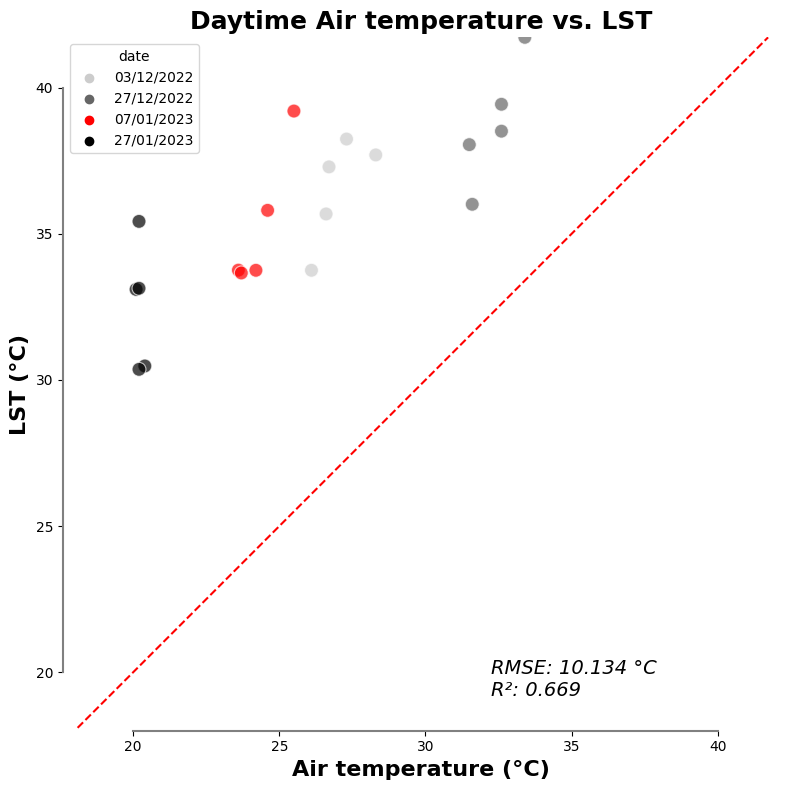

In [42]:
# Python equivalent of your R script

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns


# -------------------------
# Filter temporal == 'day'
# -------------------------
lst_air_temp_prws_day = lst_air_temp_prws[lst_air_temp_prws['temporal'] == 'day']

# -------------------------
# Paired tests
# -------------------------
t_test_result_day = stats.ttest_rel(lst_air_temp_prws_day['ta'], lst_air_temp_prws_day['lst_pred'], nan_policy='omit')
print("Paired t-test:", t_test_result_day)

wilcox_result_day = stats.wilcoxon(lst_air_temp_prws_day['ta'], lst_air_temp_prws_day['lst_pred'], zero_method='wilcox', alternative='two-sided')
print("Paired Wilcoxon test:", wilcox_result_day)

# -------------------------
# R² and RMSE
# -------------------------
r2 = np.corrcoef(lst_air_temp_prws_day['ta'], lst_air_temp_prws_day['lst_pred'])[0,1] ** 2
rmse = np.sqrt(np.mean((lst_air_temp_prws_day['ta'] - lst_air_temp_prws_day['lst_pred'])**2))
info_text = f"RMSE: {rmse:.3f} °C\nR²: {r2:.3f}"

# -------------------------
# Set plot limits
# -------------------------
min_val = min(lst_air_temp_prws_day['ta'].min(), lst_air_temp_prws_day['lst_pred'].min())
max_val = max(lst_air_temp_prws_day['ta'].max(), lst_air_temp_prws_day['lst_pred'].max())

# -------------------------
# Fix factor order for date
# -------------------------
date_order = ["03/12/2022", "27/12/2022","07/01/2023", "27/01/2023"]
lst_air_temp_prws_day['date'] = pd.Categorical(lst_air_temp_prws_day['date'], categories=date_order, ordered=True)

# -------------------------
# Create a color dictionary
# -------------------------
color_values = {
    "03/12/2022": "grey80",
    "27/12/2022": "grey40",
    "07/01/2023": "red",
    "27/01/2023": "black"
}

# Matplotlib doesn't support "grey80" directly, so convert to hex
color_values = {k: v.replace("grey80", "#CCCCCC").replace("grey40", "#666666") for k,v in color_values.items()}

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8,8))
sns.scatterplot(
    data=lst_air_temp_prws_day,  # <- filtered data
    x='ta',
    y='lst_pred',
    hue='date',
    palette=color_values,
    s=100,
    alpha=0.7
)

# Identity line
plt.plot([min_val - 2, max_val], [min_val - 2, max_val], ls='--', color='red')

# Annotate RMSE & R²
plt.text(
    x=18 + 0.6*(max_val - 18),
    y=18 + 0.05*(max_val - 18),
    s=info_text,
    fontsize=14,
    fontstyle='italic',
    color='black'
)

# Labels
plt.title("Daytime Air temperature vs. LST", fontsize=18, fontweight='bold')
plt.xlabel("Air temperature (°C)", fontsize=16, fontweight='bold')
plt.ylabel("LST (°C)", fontsize=16, fontweight='bold')

# Axis limits starting from 18
plt.xlim(18, max_val)
plt.ylim(18, max_val)

# Square axes
plt.gca().set_aspect('equal', adjustable='datalim')

# Add visible square frame around the plot panel
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('grey')

# Only bottom and left ticks visible (like ggplot2)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

# Grid and style
sns.despine(trim=True)
plt.grid(False)

# -------------------------
# Save figure
# -------------------------
plt.tight_layout()
plt.savefig("20260201_bom_day_observed_vs_predicted.png", dpi=300)
plt.show()


## 3.3. Assessment of temporal stability of fused LST 

## 3.4. Assessment of cross-date spatial pattern consistency

### a. Hotspot analysis

### b. Directional ring profiling using the urban-rural LST gradients

# References
- Ermida, S. L., Soares, P., Mantas, V., Göttsche, F.-M., & Trigo, I. F. (2020). Google earth engine open-source code for land surface temperature estimation from the landsat series. Remote Sensing, 12(9), 1471. 
- Gao, F., Masek, J., Schwaller, M., & Hall, F. (2006). On the blending of the Landsat and MODIS surface reflectance: Predicting daily Landsat surface reflectance. IEEE Transactions on Geoscience and Remote sensing, 44(8), 2207-2218.
- Mileva, N., Mecklenburg, S., & Gascon, F. (2018). New tool for spatio-temporal image fusion in remote sensing: A case study approach using Sentinel-2 and Sentinel-3 data. Image and Signal Processing for Remote Sensing Xxiv
